In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_breast_cancer
raw = load_breast_cancer()
seed = 42

In [3]:
#Diagnosis (M = malignant(cancer), B = benign(non-cancer))

In [4]:
df = pd.DataFrame(raw.data, columns=raw.feature_names)
df["diagnosis"] = raw.target       
df["diagnosis_label"] = df["diagnosis"].map({1: "B", 0: "M"})

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [7]:
df.shape

(569, 32)

<Axes: xlabel='diagnosis_label', ylabel='count'>

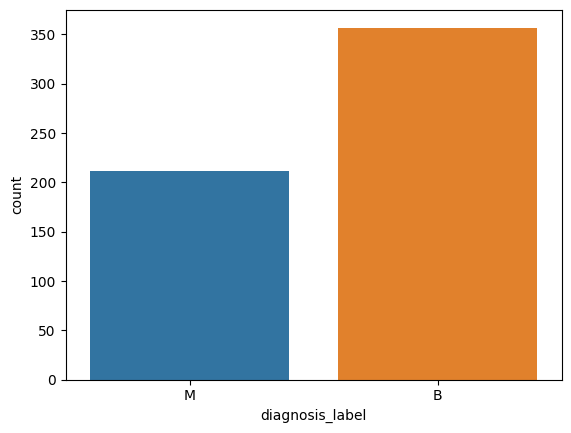

In [8]:
sns.countplot(df,x='diagnosis_label',hue='diagnosis_label')

In [9]:
df["diagnosis_label"].value_counts().to_string()

'diagnosis_label\nB    357\nM    212'

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [11]:
X = pd.DataFrame(raw.data, columns=raw.feature_names)
y = raw.target

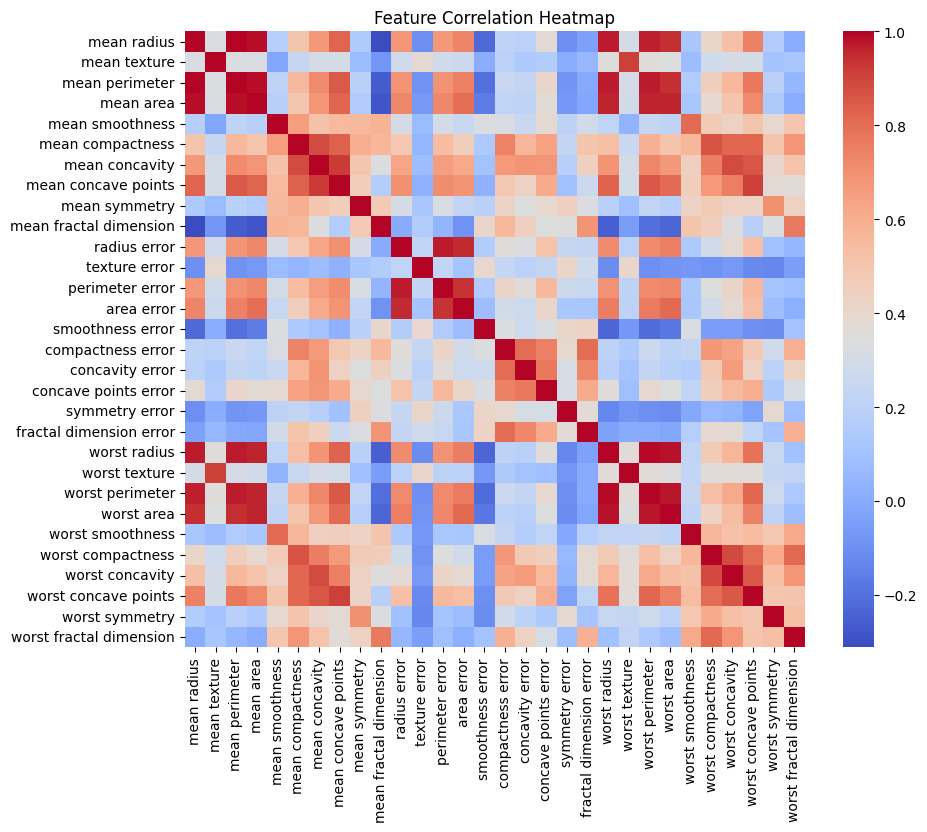

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=seed , stratify=y )

In [14]:
print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

Training shape: (455, 30)
Testing shape : (114, 30)


In [15]:
#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
pca = PCA()
pca.fit(X_train_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i,var in enumerate(explained_variance[:10]):
    print(f"PC{i+1}: {var:4f}")


PC1: 0.444135
PC2: 0.189446
PC3: 0.095434
PC4: 0.067247
PC5: 0.055177
PC6: 0.039345
PC7: 0.021818
PC8: 0.015833
PC9: 0.012788
PC10: 0.011454


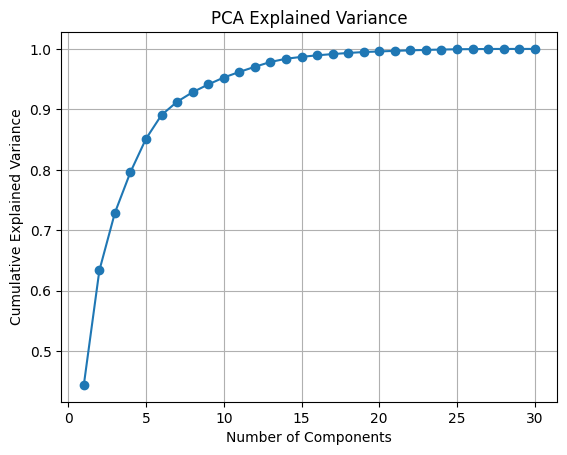

In [17]:
plt.Figure(figsize=(10,5),dpi=200)

plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)
plt.show()

In [18]:
pca_final = PCA(n_components=0.95)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("\nOriginal Features :", X.shape[1])
print("Reduced Features  :", X_train_pca.shape[1])


Original Features : 30
Reduced Features  : 10


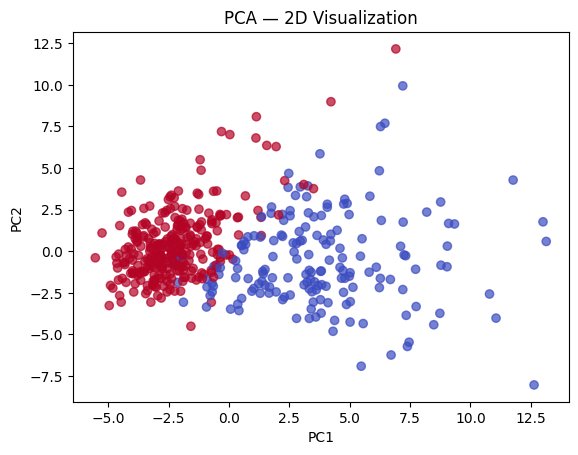

In [19]:
pca_2d = PCA(n_components=2)

X_2d = pca_2d.fit_transform(X_train_scaled)

plt.Figure(figsize=(10,8),dpi=200)

plt.scatter(X_2d[:,0],
            X_2d[:,1],
            c=y_train,
            cmap='coolwarm',
            alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA — 2D Visualization")

plt.show()

In [20]:
model = LogisticRegression(max_iter=10000)

model.fit(X_train_pca,y_train)

y_pred = model.predict(X_test_pca)
y_prob = model.predict_proba(X_test_pca)[:,1]

In [21]:
accuracy = round(accuracy_score(y_test,y_pred),4)
roc_auc = roc_auc_score(y_test,y_prob)

print("Accuracy: ",accuracy)
print("Roc-Auc Curve: ",roc_auc)

Accuracy:  0.9737
Roc-Auc Curve:  0.9953703703703703


In [22]:
classification_report_ = classification_report(y_test,y_pred)

print(classification_report_)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



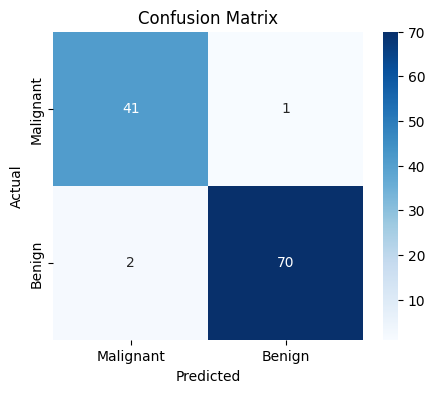

In [23]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

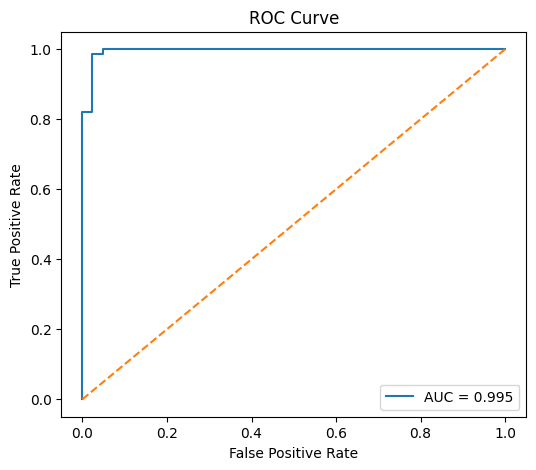

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()


In [25]:
print("\nFINAL SUMMARY\n")

print("Original Features :", X.shape[1])
print("PCA Features      :", X_train_pca.shape[1])
print("Accuracy          :", round(accuracy * 100, 2), "%")


print("\nPCA successfully reduced dimensions")
print("while maintaining high classification accuracy.")


FINAL SUMMARY

Original Features : 30
PCA Features      : 10
Accuracy          : 97.37 %

PCA successfully reduced dimensions
while maintaining high classification accuracy.
